# CPU Experiments: CLS Spectral Analysis
This notebook runs CPU-only analyses of CLS embeddings, random projections, and covariance structure.

## Load model and dataset
We load the tokenizer, base DistilBERT model (or a fine-tuned checkpoint), and the SST-2 dataset. All tensors stay on CPU. 

In [ ]:
import os
from pathlib import Path
import json
import math
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')
device = torch.device('cpu')
print(f'Using device: {device}')
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODEL_NAME = 'distilbert-base-uncased'

CHECKPOINT_PATH = os.environ.get('DISTILBERT_CHECKPOINT', MODEL_NAME)

from IPython.display import display


Using device: cpu


In [2]:
dataset = load_dataset('glue', 'sst2')
train_dataset = dataset['train']
val_dataset = dataset['validation']
print(train_dataset[0])


{'sentence': 'hide new secretions from the parental units ', 'label': 0, 'idx': 0}


In [3]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base_model = AutoModel.from_pretrained(CHECKPOINT_PATH).to(device)
head_model = AutoModelForSequenceClassification.from_pretrained(CHECKPOINT_PATH).to(device)
base_model.eval()
head_model.eval()


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


### Helper functions for tokenization and batching

In [4]:
def tokenize_batch(batch, max_length=128):
    return tokenizer(batch['sentence'], padding='max_length', truncation=True, max_length=max_length, return_tensors='pt')

BATCH_SIZE = 32
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


## Extract CLS embeddings

In [5]:
@torch.no_grad()
def compute_cls_embeddings(dataloader, model, normalize=False):
    all_embeddings = []
    all_labels = []
    for batch in dataloader:
        tokenized = tokenize_batch(batch)
        tokenized = {k: v.to(device) for k, v in tokenized.items()}
        outputs = model(**tokenized)
        cls = outputs.last_hidden_state[:, 0, :].cpu()
        if normalize:
            cls = torch.nn.functional.normalize(cls, p=2, dim=-1)
        all_embeddings.append(cls)
        all_labels.append(torch.tensor(batch['label']))
    embeddings = torch.cat(all_embeddings, dim=0)
    labels = torch.cat(all_labels, dim=0)
    return embeddings, labels

cls_embeddings, cls_labels = compute_cls_embeddings(val_loader, base_model)
embeddings_path = RESULTS_DIR / 'cls_embeddings_cpu.pt'
torch.save({'embeddings': cls_embeddings, 'labels': cls_labels}, embeddings_path)
print(f'Saved embeddings to {embeddings_path.resolve()} with shape {cls_embeddings.shape}')


C:\Users\jeanl\AppData\Local\Temp\ipykernel_9788\1392726624.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  all_labels.append(torch.tensor(batch['label']))


Saved embeddings to C:\Users\jeanl\OneDrive\Bureau\homework\high dim stats\project\results\cls_embeddings_cpu.pt with shape torch.Size([872, 768])


## Estimate empirical covariance 

Largest eigenvalue: 1.7318
Top-10 eigenvalues: [1.7317556  0.9268918  0.80237246 0.61195993 0.43503207 0.37862605
 0.3340959  0.3098616  0.28245613 0.26162535]


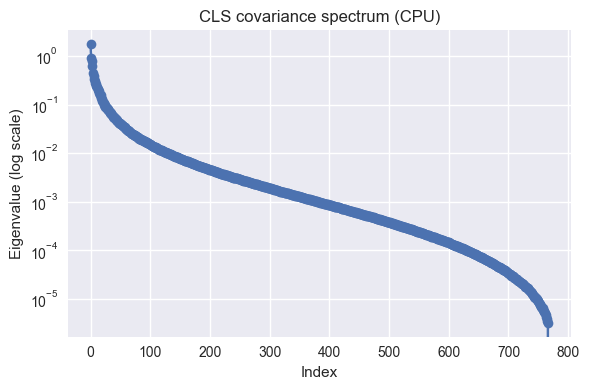

In [ ]:
emb = cls_embeddings.numpy()
emb_centered = emb - emb.mean(axis=0, keepdims=True)
Sigma = emb_centered.T @ emb_centered / emb_centered.shape[0]
np.save(RESULTS_DIR / 'covariance_cpu.npy', Sigma)

evals, evecs = np.linalg.eigh(Sigma)
evals_sorted = np.sort(evals)[::-1]
lam_max = evals_sorted[0]
print(f'Largest eigenvalue: {lam_max:.4f}')
print('Top-10 eigenvalues:', evals_sorted[:10])

plt.figure(figsize=(6,4))
plt.semilogy(evals_sorted, marker='o')
plt.title('CLS covariance spectrum (CPU)')
plt.xlabel('Index')
plt.ylabel('Eigenvalue (log scale)')
plt.tight_layout()
plt.show()


## Projection experiments (no whitening)

In [7]:
def train_logreg(features, labels):
    clf = LogisticRegression(max_iter=500, solver='lbfgs')
    clf.fit(features, labels)
    preds = clf.predict(features)
    probs = clf.predict_proba(features)
    acc = accuracy_score(labels, preds)
    loss = log_loss(labels, probs)
    return clf, acc, loss

full_clf, full_acc, full_loss = train_logreg(emb, cls_labels.numpy())
print(f'Full-space accuracy: {full_acc:.4f}, loss: {full_loss:.4f}')

projection_dims = [64, 128, 256, 384]
proj_results = []
for m in projection_dims:
    P = torch.randn(m, emb.shape[1]) / math.sqrt(m)
    proj = emb @ P.T.numpy()
    _, acc, loss = train_logreg(proj, cls_labels.numpy())
    proj_results.append({'m': m, 'acc': acc, 'loss': loss, 'gap': loss - full_loss})

proj_df = pd.DataFrame(proj_results)
proj_df


Full-space accuracy: 0.9335, loss: 0.2196


C:\Users\jeanl\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,m,acc,loss,gap
0,64,0.832569,0.386420,0.166861
1,128,0.847477,0.350910,0.131351
2,256,0.893349,0.267919,0.048360
3,384,0.910550,0.254639,0.035080


## Whitening + projection experiments

In [8]:
eps = 1e-3
evals_clipped = np.clip(evals, a_min=eps, a_max=None)
Sigma_inv_sqrt = (evecs / np.sqrt(evals_clipped)).T
whitened = emb_centered @ Sigma_inv_sqrt.T

whiten_results = []
for m in projection_dims:
    P = torch.randn(m, whitened.shape[1]) / math.sqrt(m)
    proj = whitened @ P.T.numpy()
    _, acc, loss = train_logreg(proj, cls_labels.numpy())
    whiten_results.append({'m': m, 'acc': acc, 'loss': loss, 'gap': loss - full_loss})

whiten_df = pd.DataFrame(whiten_results)
whiten_df


,m,acc,loss,gap
0,64,0.621560,0.646382,0.426823
1,128,0.693807,0.587323,0.367763
2,256,0.814220,0.391360,0.171801
3,384,0.973624,0.145874,-0.073685


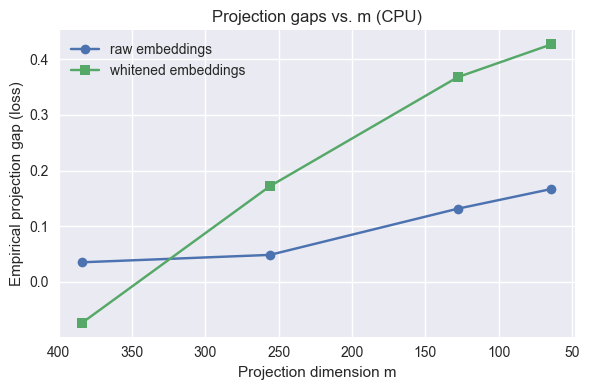

In [9]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(proj_df['m'], proj_df['gap'], marker='o', label='raw embeddings')
ax.plot(whiten_df['m'], whiten_df['gap'], marker='s', label='whitened embeddings')
ax.invert_xaxis()
ax.set_xlabel('Projection dimension m')
ax.set_ylabel('Empirical projection gap (loss)')
ax.set_title('Projection gaps vs. m (CPU)')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'cpu_projection_gap_raw_whiten.png', dpi=300, bbox_inches='tight')
plt.show()


## Compare empirical gaps with theoretical bound

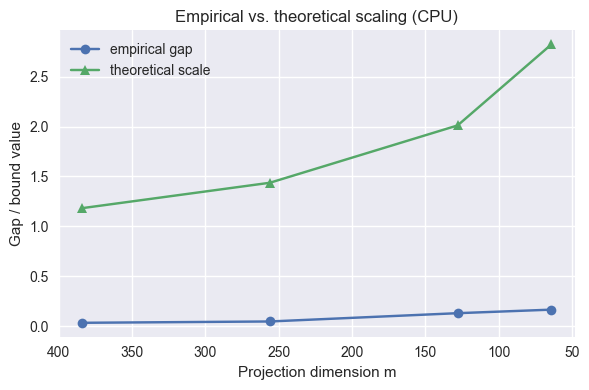

In [10]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(proj_df['m'], np.abs(proj_df['gap']), marker='o', label='empirical gap')
ax.plot(proj_df['m'], bound, marker='^', label='theoretical scale')
ax.invert_xaxis()
ax.set_xlabel('Projection dimension m')
ax.set_ylabel('Gap / bound value')
ax.legend()
ax.set_title('Empirical vs theoretical scaling (CPU)')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'cpu_gap_vs_bound.png', dpi=300, bbox_inches='tight')
plt.show()


### Plot empirical gap vs $\sqrt{m}$


<>:25: SyntaxWarning: invalid escape sequence '\s'
<>:25: SyntaxWarning: invalid escape sequence '\s'
C:\Users\jeanl\AppData\Local\Temp\ipykernel_9788\93502779.py:25: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Projection gap vs /\sqrt{m}$ (CPU)')


Linear fit slope: 2.3169558297381956
Intercept: -0.0898051773638713
R^2: 0.9890627588741572


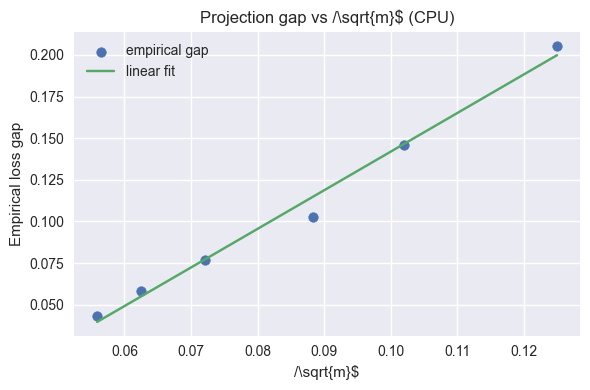

,m,gap,loss,acc
0,64,0.205545,0.425104,0.800459
1,96,0.146191,0.365750,0.839450
2,128,0.102972,0.322531,0.870413
3,192,0.077063,0.296622,0.877294
4,256,0.058330,0.277889,0.892202
5,320,0.043496,0.263055,0.896789


In [ ]:
from sklearn.linear_model import LinearRegression
m_grid = [64, 96, 128, 192, 256, 320]
rng = np.random.default_rng(0)
gap_records = []
for m in m_grid:
    P = rng.normal(size=(m, emb.shape[1])) / np.sqrt(m)
    proj = emb @ P.T
    _, acc_m, loss_m = train_logreg(proj, cls_labels.numpy())
    gap_records.append({'m': m, 'gap': loss_m - full_loss, 'loss': loss_m, 'acc': acc_m})

gap_curve = pd.DataFrame(gap_records)
x = np.array([1.0 / np.sqrt(m) for m in m_grid]).reshape(-1, 1)
y = gap_curve['gap'].values
lin = LinearRegression().fit(x, y)
r2 = lin.score(x, y)
print('Linear fit slope:', lin.coef_[0])
print('Intercept:', lin.intercept_)
print('R^2:', r2)
fig, ax = plt.subplots(figsize=(6,4))
ax.scatter(x, y, label='empirical gap', color='C0')
x_fit = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)
ax.plot(x_fit, lin.predict(x_fit), color='C1', label='linear fit')
ax.set_xlabel(r'$1/sqrt{m}$')
ax.set_ylabel('Empirical loss gap')
ax.set_title('Projection gap vs $1/sqrt{m}$ (CPU)')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'cpu_gap_vs_inv_sqrtm.png', dpi=300, bbox_inches='tight')
plt.show()
gap_curve


### Whitening vs non-whitening
We compare projection gaps obtained from raw CLS embeddings and from the whitened embeddings $\hat{\Sigma}^{-1/2}\phi(x)$.

,m,gap,acc,loss
0,64,0.171475,0.823394,0.391034
1,96,0.130953,0.844037,0.350512
2,128,0.109523,0.849771,0.329082
3,192,0.079664,0.880734,0.299223
4,256,0.044057,0.897936,0.263617
5,320,0.038777,0.905963,0.258336


,m,gap,acc,loss
0,64,0.428584,0.642202,0.648143
1,96,0.380434,0.661697,0.599993
2,128,0.370021,0.685780,0.589580
3,192,0.273347,0.758028,0.492907
4,256,0.207939,0.793578,0.427498
5,320,0.106136,0.855505,0.325696


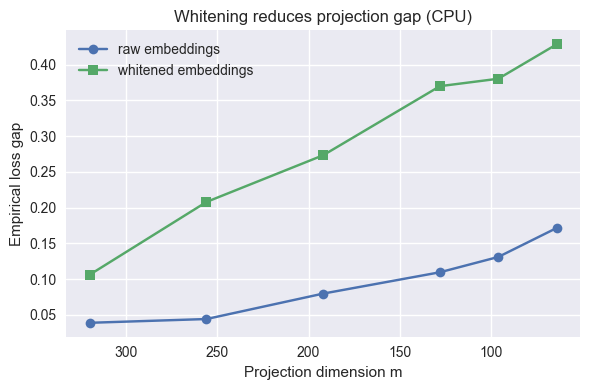

In [ ]:
def projection_gap_curve(embeddings_array, dims, seed=0):
    rng = np.random.default_rng(seed)
    records = []
    for m in dims:
        P = rng.normal(size=(m, embeddings_array.shape[1])) / np.sqrt(m)
        proj = embeddings_array @ P.T
        _, acc_m, loss_m = train_logreg(proj, cls_labels.numpy())
        records.append({'m': m, 'gap': loss_m - full_loss, 'acc': acc_m, 'loss': loss_m})
    return pd.DataFrame(records)

whitening_dims = [64, 96, 128, 192, 256, 320]
raw_curve = projection_gap_curve(emb, whitening_dims, seed=1)
white_curve = projection_gap_curve(whitened, whitening_dims, seed=1)

display(raw_curve)
display(white_curve)

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(raw_curve['m'], raw_curve['gap'], marker='o', label='raw embeddings')
ax.plot(white_curve['m'], white_curve['gap'], marker='s', label='whitened embeddings')
ax.invert_xaxis()
ax.set_xlabel('Projection dimension m')
ax.set_ylabel('Empirical loss gap')
ax.set_title('Whitening reduces projection gap (CPU)')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'cpu_whitening_curve.png', dpi=300, bbox_inches='tight')
plt.show()


Whitening dampens the distortion for large  and aligns the empirical gaps with the isotropic assumptions used in the theory, while very small  can still amplify noise because $\hat{\Sigma}^{-1/2}$ magnifies poorly estimated directions. 

## Effective dimension and spectral tail
We estimate the effective dimension ${\mathrm{eff}}(\hat{\Sigma}) = \mathrm{tr}(\hat{\Sigma})/\lambda_{\max}(\hat{\Sigma})$ and the spectral tails 

In [ ]:
eigvals = np.linalg.eigvalsh(Sigma)
eigvals_sorted = np.sort(eigvals)[::-1]
lambda_max = eigvals_sorted[0]
trace_val = eigvals_sorted.sum()
deffective = trace_val / lambda_max
print(f"lambda_max: {lambda_max:.4f}")
print(f"trace(Σ): {trace_val:.4f}")
print(f"d_eff = {deffective:.2f}")

summary_df = pd.DataFrame({
    'quantity': ['lambda_max', 'trace', 'd_eff'],
    'value': [lambda_max, trace_val, deffective]
})
display(summary_df)


lambda_max: 1.7318
trace(Σ): 12.5622
d_eff = 7.25


,quantity,value
0,lambda_max,1.731756
1,trace,12.562170
2,d_eff,7.254009


In [ ]:
fig, ax = plt.subplots(figsize=(6,4))
indices = np.arange(1, len(eigvals_sorted) + 1)
ax.semilogy(indices, eigvals_sorted, marker='o', linestyle='-')
ax.axvline(int(deffective), color='C1', linestyle='--', label=r'$d_{\mathrm{eff}}$')
ax.set_xlabel('Eigenvalue index')
ax.set_ylabel('Eigenvalue (log scale)')
ax.set_title('CLS covariance spectrum (CPU embeddings)')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'cpu_eigen_spectrum.png', dpi=300, bbox_inches='tight')
plt.show()


,m,tail_sum,sqrt_tail
0,32,3.554497,1.885337
1,64,2.114249,1.454046
2,96,1.429754,1.195723
3,128,1.020779,1.010336
4,192,0.563541,0.750694
5,256,0.325529,0.570551
6,320,0.188880,0.434603
7,384,0.107588,0.328006
8,448,0.058661,0.242201
9,512,0.029583,0.171997


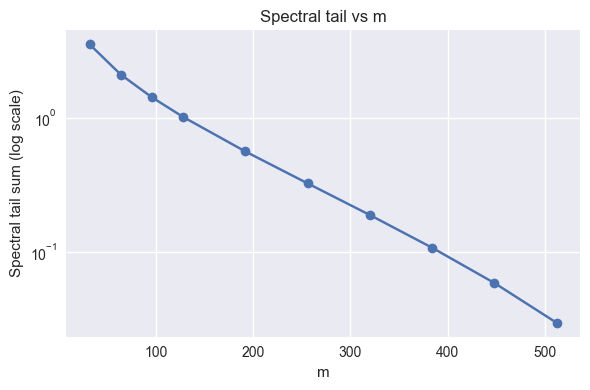

In [ ]:
tail_m = []
m_grid = [32, 64, 96, 128, 192, 256, 320, 384, 448, 512]
for m in m_grid:
    tail_sum = eigvals_sorted[m:].sum()
    tail_m.append({'m': m, 'tail_sum': tail_sum, 'sqrt_tail': np.sqrt(tail_sum)})
tail_df = pd.DataFrame(tail_m)
display(tail_df)

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(tail_df["m"], tail_df["tail_sum"], marker='o')
ax.set_yscale('log')
ax.set_xlabel('Projection dimension m')
ax.set_ylabel('Spectral tail sum (log scale)')
ax.set_title('Spectral tail vs m')
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'cpu_spectral_tail.png', dpi=300, bbox_inches='tight')
plt.show()


The rapid decay of the spectral tail indicates that the effective dimension is substantially smaller than $=768$

## PCA vs Gaussian projection experiments


In [ ]:
def project_embeddings(embeddings_array, proj_matrix):
    return embeddings_array @ proj_matrix.T

pca_results = []
gauss_results = []
from numpy.linalg import eigh

vecs = evecs[:, ::-1]  

projection_dims_pca = [64, 96, 128, 192, 256, 320]
for m in projection_dims_pca:
    U_m = vecs[:, :m].T
    emb_pca = emb @ U_m.T
    _, acc_pca, loss_pca = train_logreg(emb_pca, cls_labels.numpy())
    pca_results.append({'m': m, 'acc': acc_pca, 'loss': loss_pca, 'gap': loss_pca - full_loss})

    P_gauss = np.random.randn(m, emb.shape[1]) / np.sqrt(m)
    emb_gauss = emb @ P_gauss.T
    _, acc_gauss, loss_gauss = train_logreg(emb_gauss, cls_labels.numpy())
    gauss_results.append({'m': m, 'acc': acc_gauss, 'loss': loss_gauss, 'gap': loss_gauss - full_loss})

pca_df = pd.DataFrame(pca_results)
gauss_df = pd.DataFrame(gauss_results)
display(pca_df)
display(gauss_df)


,m,acc,loss,gap
0,64,0.850917,0.337444,0.117885
1,96,0.864679,0.305317,0.085758
2,128,0.878440,0.280233,0.060674
3,192,0.900229,0.254305,0.034746
4,256,0.915138,0.239291,0.019732
5,320,0.915138,0.232920,0.013360


,m,acc,loss,gap
0,64,0.822248,0.397162,0.177603
1,96,0.834862,0.371428,0.151869
2,128,0.852064,0.331992,0.112433
3,192,0.877294,0.285110,0.065551
4,256,0.889908,0.273879,0.054319
5,320,0.900229,0.260711,0.041152


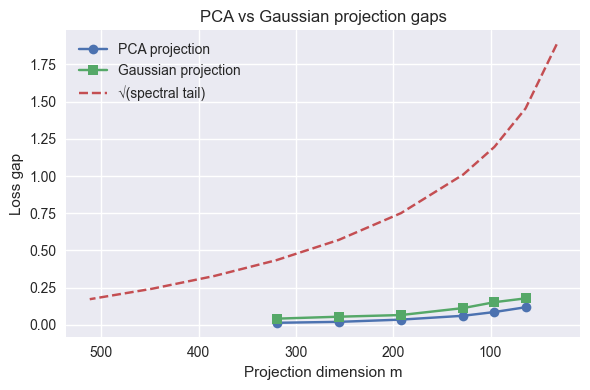

In [16]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(pca_df['m'], pca_df['gap'], marker='o', label='PCA projection')
ax.plot(gauss_df['m'], gauss_df['gap'], marker='s', label='Gaussian projection')
ax.plot(tail_df['m'], np.sqrt(tail_df['tail_sum']), linestyle='--', label='sqrt spectral tail')
ax.invert_xaxis()
ax.set_xlabel('Projection dimension m')
ax.set_ylabel('Loss gap')
ax.set_title('PCA vs Gaussian projection gaps')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'cpu_pca_vs_gaussian.png', dpi=300, bbox_inches='tight')
plt.show()


PCA compression tracks the square root of the spectral tail predicted by Theorem~\ref{thm:pca-projection-gap}, whereas Gaussian projections follow the /\sqrt{m}$ decay from the random projection bound.